# Cuaderno de clase — Fundamentos de redes en una red de ejemplo

**Modelos de Interacciones Sociales · sesión de preparación al Taller 1**

Este cuaderno recorre, paso a paso, **toda** la red de ejemplo (9 personas), con el mismo código que tus estudiantes necesitarán.

- Está pensado para **live-coding**: los comentarios explican cada línea.
- Las funciones son **generales**: sirven para esta red diminuta *y* para una red gigante (al final se prueba en una red grande).
- Al final hay una **sección de verificación**: comprueba que todo coincide con lo calculado a mano.

> ⚠️ Esta **no** es la red del taller (el club de karate). Es una red distinta para enseñar el método. Las mismas funciones se aplican a la del taller, pero aquí no la resolvemos.


In [1]:
# --- Todo lo que necesitamos ---
import numpy as np
import networkx as nx
from collections import deque          # una "cola" para el BFS
import matplotlib.pyplot as plt
%matplotlib inline

print("Listo. numpy", np.__version__, "| networkx", nx.__version__)

Listo. numpy 2.4.4 | networkx 3.6.1


## La red de ejemplo: un pueblo con 9 personas

Cada **nodo** es una persona (1..9). Cada **arista** es una amistad.

- Trío A: 1–2–3 (todos amigos)
- Puente: 3–4 y 4–5 (la persona 4 conecta los dos tríos)
- Trío B: 5–6–7 (todos amigos)
- Aparte: 8–9 (solas, sin conexión al resto)


In [2]:
# La red se guarda como LISTA DE ARISTAS: una lista de parejas (u, v).
# Es la forma mas economica de escribir un grafo.
ARISTAS = [(1,2),(1,3),(2,3),   # trio A
           (3,4),(4,5),         # la persona 4 = puente
           (5,6),(5,7),(6,7),   # trio B
           (8,9)]               # par aislado

print("La red tiene", len(ARISTAS), "amistades (aristas)")

La red tiene 9 amistades (aristas)


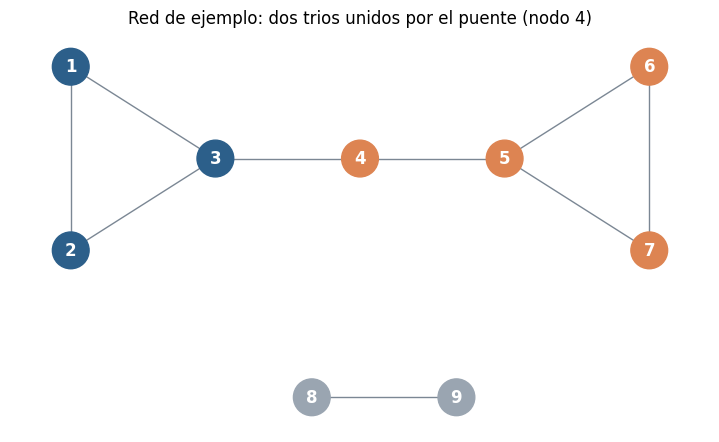

In [3]:
# Dibujemos la red para tenerla a la vista toda la clase.
# (No hace falta que los estudiantes memoricen esto; es solo para visualizar.)
pos = {1:(0,1),2:(0,-1),3:(1.5,0),4:(3,0),5:(4.5,0),6:(6,1),7:(6,-1),8:(2.5,-2.6),9:(4,-2.6)}
colores = {1:'#2C5F8A',2:'#2C5F8A',3:'#2C5F8A',4:'#DD8452',5:'#DD8452',6:'#DD8452',7:'#DD8452',8:'#9AA5B1',9:'#9AA5B1'}

G_dibujo = nx.Graph(); G_dibujo.add_edges_from(ARISTAS)
plt.figure(figsize=(7,4))
nx.draw(G_dibujo, pos, with_labels=True, node_color=[colores[n] for n in G_dibujo.nodes()],
        node_size=700, font_color='white', font_weight='bold', edge_color='#7B8794')
plt.title("Red de ejemplo: dos trios unidos por el puente (nodo 4)")
plt.show()

## 1 · Vecinos → lista de adyacencia

Los **vecinos** de una persona son sus amigos directos.

Guardamos los vecinos en un **`set`** (conjunto): sin repetidos y sin orden. Es lo correcto para vecinos.

Como el grafo es **no dirigido** (la amistad va en los dos sentidos), por cada arista `(u, v)` agregamos `u` a los vecinos de `v` **y** `v` a los de `u`.


In [4]:
def lista_adyacencia(aristas):
    """Devuelve {nodo: set(vecinos)} a partir de una lista de aristas."""
    adj = {}
    for u, v in aristas:          # desempacamos cada arista en sus dos extremos
        adj.setdefault(u, set())  # si el nodo no existe aun, lo creamos con set vacio
        adj.setdefault(v, set())
        adj[u].add(v)             # u y v son vecinos MUTUOS (grafo no dirigido)
        adj[v].add(u)
    return adj

adj = lista_adyacencia(ARISTAS)
for n in sorted(adj):
    print(n, "->", sorted(adj[n]))

1 -> [2, 3]
2 -> [1, 3]
3 -> [1, 2, 4]
4 -> [3, 5]
5 -> [4, 6, 7]
6 -> [5, 7]
7 -> [5, 6]
8 -> [9]
9 -> [8]


## 2 · Grado

El **grado** de un nodo = cuántos vecinos tiene = `len` de su conjunto de vecinos.

Lo escribimos con una **comprensión de diccionario**: el mismo `for` de siempre, pero en una línea.


In [5]:
def grados(adj):
    """Devuelve {nodo: grado}. Comprension de diccionario: {clave: valor for ...}."""
    return {n: len(vecinos) for n, vecinos in adj.items()}

g = grados(adj)
print(g)

{1: 2, 2: 2, 3: 3, 4: 2, 5: 3, 6: 2, 7: 2, 8: 1, 9: 1}


## 3 · Lema del apretón de manos

La suma de todos los grados = **2 × (número de aristas)**.

Porque cada amistad suma 1 al grado de cada uno de sus dos extremos → se cuenta dos veces.


In [6]:
suma = sum(g.values())
print("suma de grados =", suma, "  |  2 x aristas =", 2*len(ARISTAS))
print("¿coinciden?", suma == 2*len(ARISTAS))

suma de grados = 18   |  2 x aristas = 18
¿coinciden? True


## 4 · Distancias con BFS (recorrer por capas)

**BFS** visita la red por **capas**: la capa 0 es el origen, la capa 1 sus vecinos, la capa 2 los vecinos de esos, etc.

Como avanza capa por capa, **la primera vez que llega a alguien es por el camino más corto**.

Usamos una **cola** (`deque`): lo primero que entra es lo primero que sale.


In [7]:
def bfs_distancias(adj, origen):
    """Distancia mas corta (numero de saltos) desde 'origen' a cada nodo alcanzable."""
    dist = {origen: 0}            # el origen esta a distancia 0 de si mismo
    cola = deque([origen])
    while cola:
        u = cola.popleft()       # sacamos el primero de la cola
        for v in adj[u]:
            if v not in dist:            # si aun no lo visitamos...
                dist[v] = dist[u] + 1    # ...esta una capa mas lejos
                cola.append(v)
    return dist

d1 = bfs_distancias(adj, 1)
print("Distancias desde la persona 1:", d1)
print("Las personas 8 y 9 NO aparecen: no hay camino hasta ellas.")

Distancias desde la persona 1: {1: 0, 2: 1, 3: 1, 4: 2, 5: 3, 6: 4, 7: 4}
Las personas 8 y 9 NO aparecen: no hay camino hasta ellas.


## 5 · Componentes y componente gigante

Una **componente** es un grupo de nodos conectados entre sí pero aislado del resto.

Un grafo con más de una componente es **no conexo**.

La componente más grande es la **componente gigante**. Muchas medidas (distancias, densidad) se calculan **solo** ahí.


In [8]:
def componentes(adj):
    """Lista de componentes (conjuntos de nodos), de mayor a menor."""
    vistos, comps = set(), []
    for n in adj:
        if n not in vistos:
            grupo = set(bfs_distancias(adj, n))  # todo lo alcanzable desde n
            comps.append(grupo)
            vistos |= grupo
    return sorted(comps, key=len, reverse=True)

comps = componentes(adj)
print("¿La red es conexa?", len(comps) == 1)
print("Componentes:", comps)

gigante = comps[0]
aristas_gigante = [(u,v) for u,v in ARISTAS if u in gigante and v in gigante]
print("Componente gigante:", len(gigante), "nodos y", len(aristas_gigante), "aristas")

¿La red es conexa? False
Componentes: [{1, 2, 3, 4, 5, 6, 7}, {8, 9}]
Componente gigante: 7 nodos y 8 aristas


## 6 · Construir el grafo en NetworkX y medir el diámetro

Hasta aquí usamos funciones propias (**primero entender**). Ahora usamos la librería estándar, **NetworkX** (**después delegar**).

`G` es un **objeto** con **métodos** (como las clases de POO): `G.degree()`, `G.number_of_nodes()`, etc.

El **diámetro** es la distancia más larga dentro de la componente gigante. Solo tiene sentido en un grafo conexo, por eso trabajamos sobre `Gc` (la gigante).


In [9]:
G = nx.Graph()
G.add_edges_from(ARISTAS)
Gc = G.subgraph(gigante).copy()     # nos quedamos SOLO con la componente gigante

print("n =", Gc.number_of_nodes(), "| m =", Gc.number_of_edges())
print("diametro (gigante) =", nx.diameter(Gc))

n = 7 | m = 8
diametro (gigante) = 4


## 7 · Triángulos

Un **triángulo** son tres nodos todos amigos entre sí. Es la comunidad cerrada más simple.


In [10]:
# nx.triangles cuenta, por nodo, en cuantos triangulos participa.
# Cada triangulo se cuenta 3 veces (uno por vertice), por eso dividimos entre 3.
n_triangulos = sum(nx.triangles(G).values()) // 3
print("Numero de triangulos:", n_triangulos)

Numero de triangulos: 2


## 8 · La matriz de adyacencia y sus potencias

La **matriz de adyacencia** `A` tiene un `1` donde hay amistad y `0` donde no.

Dos resultados con nombre propio:

- **diag(A²)** = la diagonal de A·A = los **grados**.
- **tr(A³)/6** = el número de **triángulos** (`tr` = traza = suma de la diagonal).

Recuerda: la entrada `(i,j)` de **Aᵏ** cuenta los **recorridos** (walks, que pueden repetir nodos) de longitud `k`. Distinto de un **camino** (path), que no repite.


In [11]:
def matriz_adyacencia(aristas):
    """Devuelve (A, orden): A es la matriz de adyacencia y 'orden' las etiquetas de fila/columna."""
    orden = sorted({n for a in aristas for n in a})
    idx = {n: i for i, n in enumerate(orden)}    # nodo -> posicion
    A = np.zeros((len(orden), len(orden)), dtype=int)
    for u, v in aristas:
        A[idx[u], idx[v]] = 1
        A[idx[v], idx[u]] = 1     # simetrica: grafo no dirigido
    return A, orden

A, orden = matriz_adyacencia(aristas_gigante)
print("Matriz de adyacencia (personas", orden, "):")
print(A)

diag_A2 = np.diag(A @ A)                       # diagonal de A^2
print("\ndiag(A^2) =", diag_A2, " (deben ser los grados)")
tr_A3 = int(np.trace(np.linalg.matrix_power(A, 3)))
print("tr(A^3)/6 =", tr_A3 // 6, " (deben ser los triangulos)")

Matriz de adyacencia (personas [1, 2, 3, 4, 5, 6, 7] ):
[[0 1 1 0 0 0 0]
 [1 0 1 0 0 0 0]
 [1 1 0 1 0 0 0]
 [0 0 1 0 1 0 0]
 [0 0 0 1 0 1 1]
 [0 0 0 0 1 0 1]
 [0 0 0 0 1 1 0]]

diag(A^2) = [2 2 3 2 3 2 2]  (deben ser los grados)
tr(A^3)/6 = 2  (deben ser los triangulos)


## 9 · Densidad

Qué fracción de las amistades **posibles** existe realmente.

$$ d = \frac{2m}{n(n-1)} $$

donde **n** = número de nodos y **m** = número de aristas (en la componente gigante).


In [12]:
n = Gc.number_of_nodes()
m = Gc.number_of_edges()
densidad = 2*m / (n*(n-1))
print(f"n = {n}, m = {m}, densidad = {densidad:.4f}")

n = 7, m = 8, densidad = 0.3810


## 10 · Similaridad de Jaccard

Cuánto comparten dos nodos sus vecinos:

$$ J(u,v) = \frac{|\Gamma(u) \cap \Gamma(v)|}{|\Gamma(u) \cup \Gamma(v)|} $$

donde **Γ(x)** son los vecinos de x, **∩** es intersección, **∪** unión y **|·|** el tamaño del conjunto.


In [13]:
def jaccard(adj, u, v):
    inter = adj[u] & adj[v]     # vecinos en comun (interseccion)
    union = adj[u] | adj[v]     # todos los vecinos juntos (union)
    return len(inter) / len(union) if union else 0.0

for u, v in [(1,2),(3,5),(1,7)]:
    print(f"J({u},{v}) = {jaccard(adj,u,v):.4f}")

J(1,2) = 0.3333
J(3,5) = 0.2000
J(1,7) = 0.0000


## 11 · Centralidad: ser popular ≠ ser importante

- **Grado**: cuántos amigos tienes (popularidad).
- **Intermediación** (*betweenness*): por cuántos caminos cortos pasas (eres puente).

La persona **4** tiene grado bajo pero intermediación máxima: es el único puente entre los dos tríos.


In [14]:
import pandas as pd
cent = pd.DataFrame({
    "grado":          nx.degree_centrality(Gc),
    "intermediacion": nx.betweenness_centrality(Gc),
}).round(3).sort_values("intermediacion", ascending=False)
print(cent)
print("\nNodo con mayor intermediacion:", cent.index[0])

   grado  intermediacion
4  0.333           0.600
5  0.500           0.533
3  0.500           0.533
2  0.333           0.000
1  0.333           0.000
6  0.333           0.000
7  0.333           0.000

Nodo con mayor intermediacion: 4


## 12 · Homofilia y modelo nulo

**Homofilia** = juntarse con los similares. La medimos con la fracción de aristas **cruzadas** (entre grupos distintos).

Pero un número bajo no prueba nada **sin modelo nulo** (el escenario del azar). Dos modelos nulos:

1. **Analítico**: al azar, la fracción cruzada esperada es **2pq** (p, q = tamaños relativos de los grupos).
2. **Por permutación**: barajar las etiquetas muchas veces con la red fija (este método **escala** a redes grandes).


In [15]:
# Etiquetamos: grupo A = {1,2,3}, grupo B = {4,5,6,7}
grupos = {1:'A',2:'A',3:'A',4:'B',5:'B',6:'B',7:'B'}

# 1) Fraccion cruzada observada
cruzadas = sum(1 for u,v in aristas_gigante if grupos[u] != grupos[v])
frac_obs = cruzadas / len(aristas_gigante)
print(f"Aristas cruzadas: {cruzadas} de {len(aristas_gigante)}  ->  fraccion = {frac_obs:.4f}")

# 2) Modelo nulo analitico: 2pq
p = sum(1 for x in grupos.values() if x=='A') / len(grupos)
q = 1 - p
print(f"p = {p:.4f}, q = {q:.4f}, 2pq (esperado al azar) = {2*p*q:.4f}")

Aristas cruzadas: 1 de 8  ->  fraccion = 0.1250
p = 0.4286, q = 0.5714, 2pq (esperado al azar) = 0.4898


p-valor (permutacion) = 0.0526


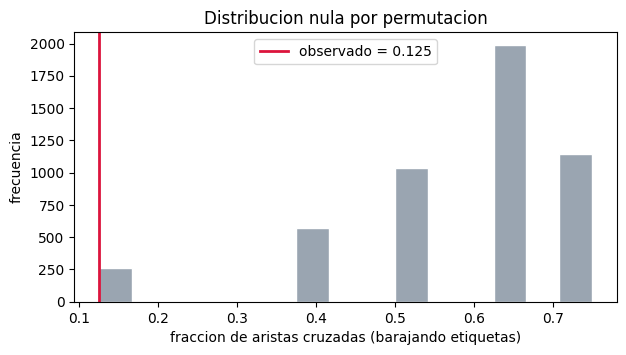

In [16]:
# 3) Modelo nulo por PERMUTACION (metodo que escala a redes grandes)
nodos = list(grupos)
etiquetas = np.array([grupos[x] for x in nodos])
pos_idx = {x:i for i,x in enumerate(nodos)}
E = [(pos_idx[u], pos_idx[v]) for u,v in aristas_gigante]

rng = np.random.default_rng(42)     # semilla fija -> resultados reproducibles
def frac_cruzada(lab):
    return np.mean([lab[i] != lab[j] for i,j in E])

sim = np.array([frac_cruzada(rng.permutation(etiquetas)) for _ in range(5000)])
p_valor = np.mean(sim <= frac_obs)   # ¿que tan raro es un valor TAN bajo, por azar?
print(f"p-valor (permutacion) = {p_valor:.4f}")

plt.figure(figsize=(7,3.5))
plt.hist(sim, bins=15, color='#9AA5B1', edgecolor='white')
plt.axvline(frac_obs, color='crimson', lw=2, label=f'observado = {frac_obs:.3f}')
plt.xlabel("fraccion de aristas cruzadas (barajando etiquetas)")
plt.ylabel("frecuencia"); plt.legend(); plt.title("Distribucion nula por permutacion")
plt.show()

### ⚠️ Lección de honestidad estadística (muy útil para el quiz)

Fíjate: el efecto **parece** grande (0.125 observado vs. 0.49 esperado)…

…pero el p-valor da **≈ 0.05–0.06**, apenas en el límite.

**¿Por qué?** Porque la red es **diminuta** (7 nodos, 8 aristas). Con tan pocos datos es difícil alcanzar significancia, aunque el efecto sea grande.

En la red **grande** del taller (más nodos y aristas) el mismo test dará un p-valor claramente significativo.

Y la hipótesis nula exacta que estamos contrastando es:

> *"Las etiquetas de grupo no tienen ninguna relación con quién es amigo de quién."*

Nunca reportes un p-valor **sin decir de qué hipótesis nula** se trata.


## 13 · ¿El mismo código sirve para una red GIGANTE?

Sí. Las funciones no saben si la red es grande o chica. Probémoslas en una red real más grande (los personajes de *Los Miserables*, 77 nodos) — **no** es la del taller, es solo para mostrar que **escala**.


In [17]:
Grande = nx.les_miserables_graph()
# nos quedamos con su componente gigante (buena practica: puede no ser conexa)
gc_nodos = max(nx.connected_components(Grande), key=len)
GG = Grande.subgraph(gc_nodos).copy()

# aplicamos EXACTAMENTE las mismas ideas
adj_grande = lista_adyacencia(list(GG.edges()))
gr = grados(adj_grande)
print("Red grande: n =", GG.number_of_nodes(), "| m =", GG.number_of_edges())
print("Nodo con mas conexiones:", max(gr, key=gr.get), "(grado", max(gr.values()), ")")
print("Diametro:", nx.diameter(GG))
print("Densidad:", round(2*GG.number_of_edges()/(GG.number_of_nodes()*(GG.number_of_nodes()-1)), 4))
top_bet = max(nx.betweenness_centrality(GG).items(), key=lambda kv: kv[1])
print("Mayor intermediacion:", top_bet[0], "(", round(top_bet[1],3), ")")
print("\n-> Mismas funciones, red 8x mas grande. A mano seria imposible; el codigo no se inmuta.")

Red grande: n = 77 | m = 254
Nodo con mas conexiones: Valjean (grado 36 )
Diametro: 5
Densidad: 0.0868


Mayor intermediacion: Valjean ( 0.57 )

-> Mismas funciones, red 8x mas grande. A mano seria imposible; el codigo no se inmuta.


## 14 · ✅ Verificación: ¿coincide todo con lo calculado a mano?

Cada `assert` compara el resultado del código con el número que calculamos con lápiz y papel.

Si alguno fallara, el cuaderno se detendría con error. **Si llega al final, todo cuadra.**


In [18]:
# --- Verificacion final contra los calculos a mano ---
assert g == {1:2,2:2,3:3,4:2,5:3,6:2,7:2,8:1,9:1},          "grados"
assert sum(g.values()) == 18 and len(ARISTAS) == 9,          "handshaking"
assert gigante == {1,2,3,4,5,6,7},                           "componente gigante (nodos)"
assert len(aristas_gigante) == 8,                            "aristas en la gigante"
assert bfs_distancias(adj,1) == {1:0,2:1,3:1,4:2,5:3,6:4,7:4},"BFS desde 1"
assert nx.diameter(Gc) == 4,                                 "diametro"
assert n_triangulos == 2,                                    "triangulos"
assert list(diag_A2) == [g[k] for k in orden],               "diag(A^2) = grados"
assert tr_A3 // 6 == 2,                                       "tr(A^3)/6 = triangulos"
assert abs(densidad - 16/42) < 1e-9,                         "densidad"
assert abs(jaccard(adj,1,2)-1/3) < 1e-9,                     "J(1,2)"
assert abs(jaccard(adj,3,5)-1/5) < 1e-9,                     "J(3,5)"
assert jaccard(adj,1,7) == 0.0,                              "J(1,7)"
assert cent.index[0] == 4,                                   "intermediacion top = nodo 4"
assert abs(frac_obs - 1/8) < 1e-9,                           "fraccion cruzada"
assert abs(2*p*q - 24/49) < 1e-9,                            "2pq"
assert p_valor < 0.10,                                       "p-valor pequeno"

print("✅ TODAS LAS VERIFICACIONES PASARON: el codigo coincide con lo que calculamos a mano.")

✅ TODAS LAS VERIFICACIONES PASARON: el codigo coincide con lo que calculamos a mano.
